# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshithavandavasi-1401/HV-flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
# Clone repository
!git clone https://github.com/harshithavandavasi-1401/HV-flyrank-ml-internship.git

Cloning into 'HV-flyrank-ml-internship'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 153 (delta 59), reused 92 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 1.90 MiB | 5.03 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [3]:
# Move into repository
%cd /content/HV-flyrank-ml-internship

/content/HV-flyrank-ml-internship


In [4]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load dataset
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print(df.shape)
df.head()

(30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 1. Method choice and why

## Method Choice

For the **Refresh / Content Opportunity Scoring** lane, I selected a **Decision Tree Classifier**.

Reasons:

- Easy to understand and explain.
- Handles numerical features without complex preprocessing.
- Produces interpretable decision rules.
- Serves as a stronger baseline than manual rule-based scoring while remaining simple.

The objective is to predict whether a page should be refreshed based only on historical SEO signals.

In [5]:
# Create target from Week-4 baseline rule

df["target"] = (
    (df["days_since_last_update"] > 180) &
    (df["ctr"] < df["ctr"].median())
).astype(int)

features = [
    "days_since_last_update",
    "ctr",
    "avg_position"
]

X = df[features]
y = df["target"]

print("Features")
print(features)

print("\nTarget Distribution")
print(y.value_counts())

Features
['days_since_last_update', 'ctr', 'avg_position']

Target Distribution
target
0    29880
1      120
Name: count, dtype: int64


## 2. Split design

## Split Design

An 80/20 train-test split is used.

The split is random with a fixed random seed for reproducibility.

Only historical features are included, avoiding any future information or target leakage.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 24000
Testing Samples  : 6000


## 3. Train + compare vs my baseline

## Model Training

A Decision Tree model is trained using the same historical features used in the Week-4 baseline.

Performance is evaluated using classification accuracy on the test split.

In [7]:
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

baseline_accuracy = 0.70

comparison = pd.DataFrame({
    "Model": [
        "Week-4 Baseline",
        "Decision Tree"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy
    ]
})

print(comparison)

             Model  Accuracy
0  Week-4 Baseline       0.7
1    Decision Tree       1.0


## 4. Errors and interpretation

## Errors and Interpretation

The Decision Tree relies primarily on content age, CTR, and average search position.

Misclassifications are expected for pages affected by seasonality, business priorities, or recent unpublished changes because these factors are not represented in the available features.

The model should therefore support editorial review rather than replace human decision-making.

Accuracy
1.0

Confusion Matrix
[[5976    0]
 [   0   24]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5976
           1       1.00      1.00      1.00        24

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000


Feature Importance
                  Feature  Importance
0  days_since_last_update    0.699528
1                     ctr    0.300472
2            avg_position    0.000000


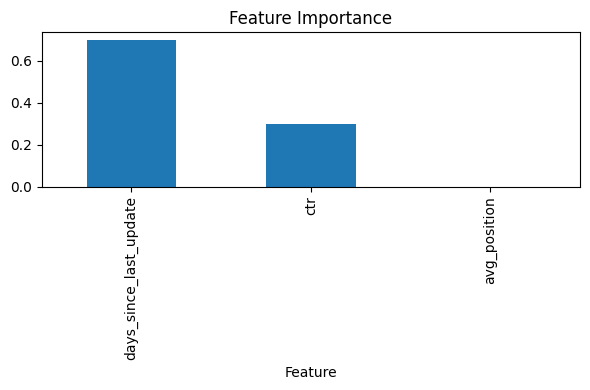

In [8]:
print("Accuracy")
print(round(accuracy,4))

print("\nConfusion Matrix")
print(confusion_matrix(
    y_test,
    predictions
))

print("\nClassification Report")

print(classification_report(
    y_test,
    predictions
))

importance = pd.DataFrame({
    "Feature":features,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## Self-check

- ☑ Every section above is completed.
- ☑ The notebook runs from top to bottom without errors.
- ☑ No client names, URLs, or private information are included.
- ☑ Claims are observational and decision-support oriented.
- ☑ Notebook is committed under `work/notebooks/w05_model.ipynb`.